# Carregamento de Dados

In [ ]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 9.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import unicodedata
import requests
import ast
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Carregar o CSV
caminho_base = '/content/drive/MyDrive/artigo_analise_jmoea/bases/artigos_autores_manual - artigos_jmoe12 - artigos_jmoe1.csv'

df = pd.read_csv(caminho_base)

# Verificar os dados
df.head()

,_id,ano,volume,numero,titulo,autores,palavras_chave,abstract,referencias,link,...,Citações,pre_keywords,university,pais,location,cidade,estado,texto_documento_preprocessed,universities_translated,universities
0,68a8cad06a09251fb721014d,2025,24,1,A Flexible UHF RFID Respiratory Sensor,"['Araujo, Jéssyca I. L.', 'Serres, Georgina K....",Index Terms\\\\nFlexible tag; Metamaterial-ins...,"In this study, we developed a Radio Frequency ...","[1] M. A. Cretikos, R. Bellomo, K. Hillman, J....",https://www.scielo.br/j/jmoea/a/XHgN4VqNZCD5cC...,...,0,"flexible tag , metamaterial inspired , respira...","['Federal University of Campina Grande', 'Fede...","['Brazil', 'Brazil', 'Italy', 'Brazil', 'Brazil']","['Campina Grande, Paraíba, Brazil', 'Campina G...","[Campina Grande, Pisa, Campina Grande, Campina...","[Paraíba, Paraíba, Pisa, Paraíba, Paraíba]",federal university of campina grande; federal ...,Universidade Federal de Campina Grande; Univer...,universidade federal de campina grande; univer...
1,68a8cad36a09251fb721014e,2025,24,1,Proposition for Path Loss Prediction Models wi...,"['Jorge Júnior, Evandro M.', 'Veiga, Antônio C...",Index Terms\\\\nDifferential Evolution; Geneti...,"In this paper, it is presented a general optim...","[1] N. Faruk, S. I. Popoola, N. T. Surajudeen-...",https://www.scielo.br/j/jmoea/a/XFZhWqy65ZzgzZ...,...,0,"differential evolution , genetic algorithm , p...","['Universidade Federal de Uberlândia', 'Univer...","['Brazil', 'Brazil', 'Brazil']","['Uberlândia, Minas Gerais, Brazil', 'Uberlând...","[Uberlândia, Uberlândia, Uberlândia]","[Minas Gerais, Minas Gerais, Minas Gerais]",universidade federal de uberlandia; universida...,Universidade Federal de Uberlandia; Universida...,universidade federal de uberlandia; universida...
2,68a8cad66a09251fb721014f,2025,24,1,A 1D-FDM Transmission Line Model for Partial D...,"['Oliveira, Rodrigo M. S. de', 'Lopes, Nathan ...",Index Terms\\\\nEffective Electrical Conductiv...,"In this paper, we present a novel numerical mo...","[1] A. Haddad and D. F. Warne, Eds., Advances ...",https://www.scielo.br/j/jmoea/a/WQxvPr4GjWVKVw...,...,0,"effective electrical conductivity , finite dif...","['Federal University of Pará', 'UFPA-ITEC', 'E...","['Brazil', 'Brazil']","['Belém, Brazil', 'Belém, Brazil']","[Belém, Belém]","[Brazil, Brazil]",federal university of para; ufpa itec; eletrob...,Universidade Federal do Pará; Universidade Fed...,universidade federal do para; universidade fed...
3,68a8cad86a09251fb7210150,2025,24,1,Assessment of Planar Transmission Line with St...,"['Fonseca, Daniel A. B.', 'Costa, Luís G. da S...",Index Terms\\\\nPlanar transmission line; powe...,This study investigates the effectiveness of e...,"[1] D. K. Mahanta and O. Andrew, “Transformer ...",https://www.scielo.br/j/jmoea/a/vr67fPZqgtyFVb...,...,0,"planar transmission line , power transformer ,...","['Universidade Federal de Juiz de Fora', 'Univ...","['Brazil', 'Brazil', 'Brazil', 'Brazil', 'Braz...","['Juiz de Fora, Minas Gerais, Brazil', 'Juiz d...","[Juiz de Fora, Juiz de Fora, Juiz de Fora, Jui...","[Minas Gerais, Minas Gerais, Minas Gerais, Min...",universidade federal de juiz de fora; universi...,Universidade Federal de Juiz de Fora; Universi...,universidade federal de juiz de fora; universi...
4,68a8cada6a09251fb7210151,2025,24,1,Space-fed Array Variations of E-shape and U-sl...,"['Deshmukh, Amit A.', 'Parvez, Adil', 'Chavali...",Index Terms\\\\nBroadband High gain microstrip...,Space-fed array comprising of E-shape or U-slo...,"[1] G. Kumar, K. P. Ray, Broadband Microstrip ...",https://www.scielo.br/j/jmoea/a/Nkr93SPpvfsMLP...,...,0,"broadband high gain microstrip antenna , shap...",['Dwarkadas Jivanlal Sanghvi College of Engine...,"['India', 'India', 'India', 'India']","['Mumbai, India', 'Mumbai, India', 'Mumbai, In...","[Mumbai, Mumbai, Mumbai, Mumbai]","[India, India, India, India]",dwarkadas jivanlal sanghvi college of engineer...,Faculdade de Engenharia Dwarkadas Jivanlal San...,faculdade de

# Pré-processamento

In [ ]:
#Função para converter strings em listas reais
def converter_para_lista(valor):
    """
    Tenta converter uma string formatada como lista (ex: "['Autor A', 'Autor B']")
    em uma lista Python. Se falhar, retorna uma lista vazia.
    """
    try:
        # ast.literal_eval é mais seguro que o 'eval' comum
        return ast.literal_eval(str(valor))
    except:
        return []

In [ ]:
# Aplicar a conversão na coluna de autores
df['lista_autores'] = df['autores'].apply(converter_para_lista)

In [ ]:
# Explodir e Contar Frequência
# O comando 'explode' transforma cada item da lista em uma nova linha no DataFrame
# O 'value_counts' conta quantas vezes cada autor aparece
autores_frequentes = df.explode('lista_autores')['lista_autores'].value_counts()

In [ ]:
# Criar DataFrame de trabalho para os autores únicos
df_autores = autores_frequentes.to_frame().reset_index()
df_autores.columns = ['autores', 'contagem']

In [ ]:
print(f"Total de autores únicos identificados: {len(df_autores)}")

Total de autores únicos identificados: 1598


In [ ]:
def remover_acentos(texto):
    """Remove acentos utilizando normalização Unicode (NFKD)."""
    if not texto: return ""
    nfkd_form = unicodedata.normalize('NFKD', str(texto))
    return u"".join([c for c in nfkd_form if not unicodedata.combining(c)])

In [ ]:
def normalizacao_especifica(texto):
    """
    Trata abreviações comuns em nomes brasileiros.
    Substitui 'jr' por 'junior' para não quebrar a lógica de último nome.
    """
    texto = re.sub(r'\bjr\b\.?', 'junior', texto)
    return texto

In [ ]:
def extrair_nomes(nome_completo):
    """
    Divide o nome completo para isolar o primeiro nome (usado na API de gênero)
    e o último nome (sobrenome principal).
    Lida com formatos 'Nome Sobrenome' e 'Sobrenome, Nome'.
    """
    # Remove espaços duplos
    nome_completo = re.sub(' +', ' ', str(nome_completo)).strip()

    # Caso o nome esteja no formato: 'Sobrenome, Nome'
    if ',' in nome_completo:
        partes = nome_completo.split(',')
        sobrenome = partes[0].strip()
        primeiro_nome = partes[1].strip().split(' ')[0]
        return primeiro_nome, sobrenome

    # Caso o nome esteja no formato padrão: 'Nome Sobrenome'
    else:
        partes = nome_completo.split(' ')
        if len(partes) >= 2:
            return partes[0], partes[-1]
        # Se for nome único
        return nome_completo, ''

In [ ]:
# Limpeza básica: remover acentos, colocar em minúsculo e tratar 'junior'
df_autores['limpo'] = (
    df_autores['autores']
    .apply(remover_acentos)
    .str.lower()
    .apply(normalizacao_especifica)
)

# Segmentação: Criar colunas separadas para Primeiro e Último nome
# O lambda aplica a função e o pd.Series transforma o retorno em duas colunas
df_autores[['primeiro_nome', 'ultimo_nome']] = df_autores['limpo'].apply(
    lambda x: pd.Series(extrair_nomes(x))
)

# Visualização do resultado
print("Variável 'autores_frequentes' criada e nomes limpos.")
print("Pronto para enviar a coluna 'primeiro_nome' para a API de Gênero.")
df_autores.head()

Variável 'autores_frequentes' criada e nomes limpos.
Pronto para enviar a coluna 'primeiro_nome' para a API de Gênero.


,autores,contagem,limpo,primeiro_nome,ultimo_nome
0,"Gomes Neto, Alfredo",24,"gomes neto, alfredo",alfredo,gomes neto
1,"Campos, Antonio Luiz Pereira de Siqueira",15,"campos, antonio luiz pereira de siqueira",antonio,campos
2,"Sodré Junior, Arismar Cerqueira",12,"sodre junior, arismar cerqueira",arismar,sodre junior
3,"Sadowski, Nelson",12,"sadowski, nelson",nelson,sadowski
4,"Batistela, Nelson J.",12,"batistela, nelson j.",nelson,batistela


In [ ]:
# Limpeza básica: remover acentos, colocar em minúsculo e tratar 'junior'
df_autores['limpo'] = (
    df_autores['autores']
    .apply(remover_acentos)
    .str.lower()
    .apply(normalizacao_especifica)
)

In [ ]:
# Segmentação: Criar colunas separadas para Primeiro e Último nome
# O lambda aplica a função e o pd.Series transforma o retorno em duas colunas
df_autores[['primeiro_nome', 'ultimo_nome']] = df_autores['limpo'].apply(
    lambda x: pd.Series(extrair_nomes(x))
)

In [ ]:
print("Variável 'autores_frequentes' criada e nomes limpos.")
print("Pronto para enviar a coluna 'primeiro_nome' para a API de Gênero.")
df_autores.head()

Variável 'autores_frequentes' criada e nomes limpos.
Pronto para enviar a coluna 'primeiro_nome' para a API de Gênero.


,autores,contagem,limpo,primeiro_nome,ultimo_nome
0,"Gomes Neto, Alfredo",24,"gomes neto, alfredo",alfredo,gomes neto
1,"Campos, Antonio Luiz Pereira de Siqueira",15,"campos, antonio luiz pereira de siqueira",antonio,campos
2,"Sodré Junior, Arismar Cerqueira",12,"sodre junior, arismar cerqueira",arismar,sodre junior
3,"Sadowski, Nelson",12,"sadowski, nelson",nelson,sadowski
4,"Batistela, Nelson J.",12,"batistela, nelson j.",nelson,batistela


In [ ]:
# Definir o caminho de salvamento
caminho_visualizacao = 'pre_visualizacao_autores.csv'

In [ ]:
# Criamos uma cópia apenas com as colunas que importam para a conferência visual.
# A ordem ajuda a comparar o 'original' com o 'limpo' e as divisões.
colunas_ordem = ['autores', 'contagem', 'limpo', 'primeiro_nome', 'ultimo_nome']
df_conferencia = df_autores[colunas_ordem].copy()

In [ ]:
# Guardamos em CSV sem o índice (index=False) para o ficheiro ficar mais limpo.
df_conferencia.to_csv(caminho_visualizacao, index=False)

In [ ]:
print(f" Documento de pré-visualização gerado com sucesso!")
print(f" Local do ficheiro: {caminho_visualizacao}")
print(f" Total de autores únicos para conferir: {len(df_conferencia)}")

 Documento de pré-visualização gerado com sucesso!
 Local do ficheiro: pre_visualizacao_autores.csv
 Total de autores únicos para conferir: 1598


In [ ]:
df_conferencia.head(15)

,autores,contagem,limpo,primeiro_nome,ultimo_nome
0,"Gomes Neto, Alfredo",24,"gomes neto, alfredo",alfredo,gomes neto
1,"Campos, Antonio Luiz Pereira de Siqueira",15,"campos, antonio luiz pereira de siqueira",antonio,campos
2,"Sodré Junior, Arismar Cerqueira",12,"sodre junior, arismar cerqueira",arismar,sodre junior
3,"Sadowski, Nelson",12,"sadowski, nelson",nelson,sadowski
4,"Batistela, Nelson J.",12,"batistela, nelson j.",nelson,batistela
5,"Dmitriev, Victor",12,"dmitriev, victor",victor,dmitriev
6,"Oliveira, Rodrigo M. S. de",10,"oliveira, rodrigo m. s. de",rodrigo,oliveira
7,"D’Assunção, Adaildo Gomes",9,"d’assuncao, adaildo gomes",adaildo,d’assuncao
8,"segatto, marcelo e. v.",8,"segatto, marcelo e. v.",marcelo,segatto
9,"Silva, José P.",8,"silva, jose p.",jose,silva


# Mapa de autores

In [ ]:
mapa_mestre = {
     # Grupo ab_bouari
    'bouari, abdou h. a. a.': 'bouari, abdou-halique a. a.',
    # Grupo ad_d’assuncao
    'd’assuncao, adaildo g.': 'd’assuncao, adaildo gomes',
    # Grupo ad_guimaraes
    'guimaraes, adller o.': 'guimaraes, adller de o.',
    # Grupo ad_herbster
    'herbster, adolfo f.': 'herbster, adolfo fernandes',
    # Grupo ad_lima
    'lima, adelson m.': 'lima, adelson menezes',
    # Grupo al_paterno
    'paterno, aleksander s.': 'paterno, aleksander sade',
    # Grupo al_santos (Alexandre Bessa)
    'santos, alexandre b. dos': 'santos, alexandre bessa dos',
    # Grupo al_serres
    'serres, alexandre j. r.': 'serres, alexandre jean rene',
    'serres, alexandre jean r.': 'serres, alexandre jean rene',
    # Grupo am_barboza
    'barboza, amanda g.': 'barboza, amanda gomes',
    # Grupo am_nazeri
    'nazeri, amir. h': 'nazeri, amir hossein',
    # Grupo am_santos
    'santos, amanda': 'santos, amanda beatriz cunha dos',
    # Grupo an_barbero
    'barbero, andres p. l.': 'barbero, andres pablo lopez',
    # Grupo an_campos
    'campos, antonio luiz p. s.': 'campos, antonio luiz pereira de siqueira',
    'campos, antonio l. p. s.': 'campos, antonio luiz pereira de siqueira',
    # Grupo an_cruz
    'cruz, andre': 'cruz, andre felipe souza da',
    # Grupo an_garcia
    'garcia, anilton s.': 'garcia, anilton salles',
    # Grupo an_lazzaretti
    'lazzaretti, andre e.': 'lazzaretti, andre eugenio',
    # Grupo an_sombra
    'sombra, antonio s. b.': 'sombra, antonio sergio b.',
    # Grupo ba_shahu (Correção de digitação de 'lai' para 'lal')
    'shahu, babu lai': 'shahu, babu lal',
    # Grupo c._rego (Padronização para a versão com 'do')
    'rego, c. g.': 'rego, c. g. do',
    # Grupo ca_castellani
    'castellani, carlos e. s.': 'castellani, carlos eduardo s.',
    # Grupo ca_frances
    'frances, carlos r. l.': 'frances, carlos renato l.',
    'frances, carlos': 'frances, carlos renato l.',
    # Grupo ca_rego (Cassio Goncalves do Rego)
    'rego, cassio g.': 'rego, cassio goncalves do',
    'rego, c. g. do': 'rego, cassio goncalves do',
    'rego, c. g.': 'rego, cassio goncalves do',
    # Grupo ca_ron
    'ron, carlos v. rodriguez': 'ron, carlos rodriguez vinicio',
    # Grupo ca_sartori
    'sartori, carlos. a. f.': 'sartori, carlos antonio franca',
    'sartori, carlos a. f.': 'sartori, carlos antonio franca',
    # Grupo cr_gallep
    'gallep, cristiano m': 'gallep, cristiano m.',
    # Grupo da_fonseca
    'fonseca, daniel': 'fonseca, daniel a. b.',
    # Grupo da_santos (Unificando Danila para Danilo conforme sua marcação)
    'santos, danila araujo': 'santos, danilo f. s.',
    # Grupo di_cardoso
    'cardoso, diego l.': 'cardoso, diego lisboa',
    # Grupo di_coelho
    'coelho, diogo': 'coelho, diogo v n',
    # Grupo di_fernandes
    'fernandes, diego': 'fernandes, diego cassio garcia',
    # Grupo di_silva
    'silva, diego k. n. da': 'silva, diego kasuo nakata da',
    # Grupo ed_dureck
    'dureck, eduardo h.': 'dureck, eduardo henrique',
    # Grupo el_santos
    'santos, eliel p.': 'santos, eliel p. dos',
    # Grupo en_ghasemi-mizuji
    'ghasemi-mizuji, ensiyeh': 'ghasemi-mizuji, ensieh',
    # Grupo ev_akpari
    'akpari, evans w.': 'akpari, evans wilson',
    # Grupo fa_barros
    'barros, fabricio j. b.': 'barros, fabricio jose brito',
    # Grupo fa_correra
    'correra, fatima s.': 'correra, fatima salete',
    # Grupo fa_deynu
    'deynu, faith k.': 'deynu, faith kwaku',
    # Grupo fa_lima
    'lima, fabio o.': 'lima, fabio de o.',
    # Grupo fi_mendes
    'mendes, filomena b. r.': 'mendes, filomena barbosa r.',
    # Grupo ge_cavalcante
    'cavalcante, gervasio': 'cavalcante, gervasio p. s.',
    # Grupo gl_ramos
    'ramos, glaucio l.': 'ramos, glaucio lopes',
    # Grupo gl_siqueira
    'siqueira, glaucio l.': 'siqueira, glaucio lima',
    'siqueira, glaucio. l.': 'siqueira, glaucio lima',
    # Grupo h._silva (Hugo Vinicius Leao e Silva)
    'silva, h. v. l.': 'silva, hugo vinicius leao e',
    # Grupo he_gomes
    'gomes, herminio': 'gomes, herminio s.',
    # Grupo he_oliveira
    'oliveira, hebio j. b.': 'oliveira, hebio j. b. de',
    # Grupo he_rocha
    'rocha, helder': 'rocha, helder r. de o.',
    # Grupo hy_kalinowski
    'kalinowski, hypolito j.': 'kalinowski, hypolito jose',
    # Grupo i._chabu
    'chabu, i. e.': 'chabu, i.e.',
    # Grupo ia_coutinho
    'coutinho, ianes b. g.': 'coutinho, ianes barbosa grecia',
    # Grupo is_silva
    'silva, isaac b. t. da': 'silva, isaac barros tavares da',
    # Grupo j._araujo e ja_araujo (Jasmine Araujo)
    'araujo, j.p.l.': 'araujo, jasmine p. l.',
    'araujo, j. p. l.': 'araujo, jasmine p. l.',
    'araujo, jasmine': 'araujo, jasmine p. l.',
    # Grupo j._bastos (Joao Pedro Bastos)
    'bastos, j. p. a.': 'bastos, joao pedro a.',
    'bastos, j.p.a': 'bastos, joao pedro a.',
    'bastos, j.p. a.': 'bastos, joao pedro a.',
    'bastos, joao p. a.': 'bastos, joao pedro a.',
    # Grupo j._lacava (José Carlos da Silva Lacava)
    'lacava, j.c. da s.': 'lacava, jose carlos da silva',
    'lacava, j. c. da s.': 'lacava, jose carlos da silva',
    'lacava, j. c. s.': 'lacava, jose carlos da silva',
    # Grupo j._silva (Jose Patrocinio da Silva)
    'silva, j. p. da': 'silva, jose patrocinio da',
    'silva, jose p.': 'silva, jose patrocinio da',
    # Grupo ja_silva (Jair Silva)
    'silva, jair a.': 'silva, jair a. l.',
    # Grupo je_nascimento
    'nascimento, jehan f. do': 'nascimento, jehan fonseca do',
    'nascimento, jehan f.': 'nascimento, jehan fonseca do',
    # Grupo je_silva (Jean Carlos Cardozo da Silva)
    'silva, jean carlos c. da': 'silva, jean carlos cardozo da',
    # Grupo jo_almeida
    'almeida, jorge v. de': 'almeida, jorge virgilio de',
    # Grupo jo_cardoso
    'cardoso, jose r.': 'cardoso, jose roberto',
    # Grupo jo_costa
    'costa, joao c w a': 'costa, joao c. w. a.',
    # Grupo jo_fabris
    'fabris, jose l.': 'fabris, jose luis',
    # Grupo jo_oliveira (Joao Guilherme Domingos)
    'oliveira, joao guilherme domingos': 'oliveira, joao guilherme domingos de',
    # Grupo jo_silva
    'silva, joao batista r.': 'silva, joao batista rosa',
    # Grupo jo_souza (Jorge)
    'souza, jorge m.': 'souza, jorge',
    # Grupo ju_nascimento
    'nascimento, julio s.': 'nascimento, julio a. s. do',
    # Grupo ka_costa
    'costa, karlo': 'costa, karlo q. da',
    # Grupo ke_santos
    'santos, kenedy marconi g.': 'santos, kenedy marconi g. dos',
    'santos, kenedy m. g. dos': 'santos, kenedy marconi g. dos',
    # Grupo l._silva (Leandro Aurelio)
    'silva, l. a. da': 'silva, leandro aurelio da',
    # Grupo l._silva mello (Luiz Alencar)
    'silva mello, l. a. r. da': 'silva mello, luiz alencar reis da',
    'silva mello, l. da': 'silva mello, luiz alencar reis da',
    # Grupo la_mendonca
    'mendonca, laercio m.': 'mendonca, laercio m. de',
    # Grupo la_novo
    'novo, lauro r. g. s. l.': 'novo, lauro r. g. s. lourenco',
    # Grupo le_gonsioroski (Leonardo Henrique Gonsioroski Furtado da Silva)
    'gonsioroski, leonardo h.': 'silva, leonardo henrique gonsioroski furtado da',
    'gonsioroski, leonardo': 'silva, leonardo henrique gonsioroski furtado da',
    # Grupo le_manera
    'manera, leandro': 'manera, leandro tiago',
    # Grupo le_matos
    'matos, leni j.': 'matos, leni j. de',
    'matos, leni': 'matos, leni j. de',
    # Grupo le_menezes
    'menezes, leonardo r.a.x.': 'menezes, leonardo r.a.x. de',
    # Grupo le_silva (Leandro Aurelio)
    'silva, leandro a. da': 'silva, leandro aurelio da',
    # Grupo lu_alexandre
    'alexandre, luciano c.': 'alexandre, luciano camilo',
    # Grupo lu_mello (Luiz Alencar Reis da Silva Mello)
    'mello, luiz da silva': 'mello, luiz alencar reis da silva',
    'mello, luiz a. r. da silva': 'mello, luiz alencar reis da silva',
    # Grupo lu_silva (Luis Cicero Bezerra da Silva)
    'silva, luis g. da': 'silva, luis cicero bezerra da',
    # Grupo m._almeida (Marta Pudwell Chaves de Almeida)
    'almeida, m. p. c.': 'almeida, marta pudwell chaves de',
    'almeida, m.p.c.': 'almeida, marta pudwell chaves de',
    # Grupo m._melo (Marcos T. de Melo)
    'melo, m. t. de': 'melo, marcos t. de',
    'melo, m. q.': 'melo, marcilio', # Separando Marcilio de Marcos
    # Grupo m._oliveira (Manuelle Oliveira)
    'oliveira, m. r. t. de': 'oliveira, manuelle r. t. de',
    'oliveira, m. r. t.': 'oliveira, manuelle r. t. de',
    # Grupo m._pontes (Maria Jose Pontes)
    'pontes, m. j.': 'pontes, maria jose',
    # Grupo ma_alencar (Marina vs Marcelo)
    'alencar, marina de o.': 'alencar, marina de oliveira',
    'alencar, marcelo': 'alencar, marcelo s.',
    # Grupo ma_goncalves (Mariane vs Marcos)
    'goncalves, marcos s.': 'goncalves, marcos',
    # Grupo ma_mosso
    'mosso, marbey': 'mosso, marbey manhaes',
    'mosso, marbey m.': 'mosso, marbey manhaes',
    # Grupo ma_novo
    'novo, marcela s.': 'novo, marcela silva',
    # Grupo ma_perotoni
    'perotoni, marcelo b.': 'perotoni, marcelo bender',
    # Grupo ma_segatto
    'segatto, marcelo e. v.': 'segatto, marcelo eduardo vieira',
    'segatto, marcelo': 'segatto, marcelo eduardo vieira',
    'segatto, marcelo e.v.': 'segatto, marcelo eduardo vieira',
    # Grupo ma_segundo
    'segundo, marcos t. b.': 'segundo, marcos tulio antunes bezerra',
    # Grupo ma_souza
    'souza, mauren a.': 'souza, mauren a. de',
    # Grupo mu_romero
    'romero, murilo a.': 'romero, murilo araujo',
    # Grupo na_vijaykumar
    'vijaykumar, nadamudi': 'vijaykumar, nandamudi. l.',
    # Grupo ni_cunha
    'cunha, nilson h. o.': 'cunha, nilson henrique o.',
    # Grupo ni_rodrigues
    'rodrigues, nilton r. n. m.': 'rodrigues, nilton rodolfo n. m.',
    # Grupo ot_lavor
    'lavor, otavio p.': 'lavor, otavio paulino',
    # Grupo p._castellanos (Pedro Vladimir Gonzalez Castellanos)
    'castellanos, p. v. g.': 'castellanos, pedro gonzalez',
    'castellanos, p.v.g.': 'castellanos, pedro gonzalez',
    'castellanos, pedro v. g.': 'castellanos, pedro gonzalez',
    # Grupo pa_silva
    'silva, paulo henique da f.': 'silva, paulo henrique da fonseca',
    # Grupo ra_araujo
    'araujo, ramon c.f.': 'araujo, ramon c. f.',
    # Grupo ra_figueiredo
    'figueiredo, rafael c.': 'figueiredo, rafael carvalho',
    # Grupo ra_freire
    'freire, raimundo c. s.': 'freire, raimundo carlos silverio',
    # Grupo re_frances
    'frances, renato': 'frances, renato l.',
    # Grupo ri_kamikawachi
    'kamikawachi, ricardo c.': 'kamikawachi, ricardo canute',
    # Grupo ro_oliveira (Rodrigo M. S. de Oliveira)
    'oliveira, rodrigo m.s. de': 'oliveira, rodrigo m. s. de',
    # Grupo ro_silva
    'silva, rogerio': 'silva, rogerio m. l.',
    # Grupo ru_lira
    'ruann victor de a.': 'lira, ruann victor de andrade',
    # Grupo t._sousa
    'sousa, t. r.': 'sousa, t. r. de',
    # Grupo ta_carvalho
    'carvalho, tassio': 'carvalho, tassio costa de',
    # Grupo th_coelho
    'coelho, thiago v n': 'coelho, thiago v. n.',
    # Grupo ui_dreyer
    'dreyer, uilian j.': 'dreyer, uilian jose',
    # Grupo vi_dmitriev
    'dmitriev, victor a.': 'dmitriev, victor',
    # Grupo vi_singh
    'singh, vinod k.': 'singh, vinod kumar',
    # Grupo wa_carpes junior
    'carpes junior, walter p.': 'carpes junior, walter pereira',
    # Grupo an_andrade
    'andrade, f. j. a.': 'andrade, fernando j. a.',
    # Grupo am_barboza (Amanda)
    'barboza, a. g.': 'barboza, amanda gomes',
    # Grupo sa_bandiri
    'bandiri, s. y. m.': 'bandiri, sabi y.m.',
    # Grupo ca_wengerkievicz
    'wengerkievicz, c. a. c.': 'wengerkievicz, carlos a. c.',
    # Grupo an_campos (Antônio Luiz Pereira de Siqueira Campos)
    'campos, a. l. p. s.': 'campos, antonio luiz pereira de siqueira',
    'campos, antônio l. p. s.': 'campos, antonio luiz pereira de siqueira',
    'campos, antonio l. p. s.': 'campos, antonio luiz pereira de siqueira',
    'campos, antonio luiz p. s.': 'campos, antonio luiz pereira de siqueira',
    'campos, antonio luiz pereira siqueira': 'campos, antonio luiz pereira de siqueira',
    # Grupo ev_conforti
    'conforti, e.': 'conforti, evandro',
    # Grupo ti_sutili
    'sutili, t.': 'sutili, tiago',
    # Grupo il_bianchi
    'bianchi, i.': 'bianchi, ildefonso',
    # Grupo al_gomes (Alfredo Gomes Neto)
    'gomes neto, a.': 'gomes neto, alfredo',
    'gomes, alfredo': 'gomes neto, alfredo',
    'gomes, alfrêdo': 'gomes neto, alfredo',
    'gomes, a.': 'gomes neto, alfredo',
    'g. neto, alfredo': 'gomes neto, alfredo',
    # Grupo cr_gallep
    'gallep, c. m.': 'gallep, cristiano m.',
    'gallep, cristiano m': 'gallep, cristiano m.',
    # Grupo hu_hernandez-figueroa
    'hernández-figueroa, h. e.': 'hernández-figueroa, hugo e.',
    'hernandez-figueroa, hugo e.': 'hernández-figueroa, hugo e.',
    # Grupo gl_siqueira
    'siqueira, g. l.': 'siqueira, gláucio lima',
    'siqueira, glaucio l.': 'siqueira, gláucio lima',
    'siqueira, gláucio. l.': 'siqueira, gláucio lima',
    # Grupo na_vijaykumar (Unificando para o nome base)
    'vijaykumar, n. l.': 'vijaykumar, nadamudi',
    'vijaykumar, nandamudi. l.': 'vijaykumar, nadamudi',
    # Grupo co_rubio-mercedes
    'rubio-mercedes, c. e.': 'rubio-mercedes, cosme e.',
    # Grupo ad_lisboa
    'lisboa, a. c.': 'lisboa, adriano c.',
    # Grupo ah_errkik
    'errkik, a.': 'errkik, ahmed',
    # Grupo an_canavitsas
    'canavitsas, a.': 'canavitsas, ângelo a. c.',
    # Grupo se_ebadzadeh
    'ebadzadeh, s. r.': 'ebadzadeh, seyedeh roghaye',
    # Grupo vi_dmitriev
    'dmitriev, v.': 'dmitriev, victor',
    # Grupo ne_chattoraj
    'chattoraj, n.': 'chattoraj, neela',
    # Grupo sa_goncalves
    'gonçalves, s. t. m': 'gonçalves, sandro trindade mordente',
    # Grupo sa_ibnyaich
    'ibnyaich, s.': 'ibnyaich, saida',
    # Grupo al_flores_filho
    'filho, a. f. f.': 'flores filho, aly ferreira',
    # Grupo va_oliveira
    'oliveira, v.': 'oliveira, valmir de',
    # Grupo al_bordonalli
    'bordonalli, a': 'bordonalli, aldário',
    # Grupo ma_pontes
    'pontes, m. s.': 'pontes, marlene s.',
    # Grupo ar_sodre (Arismar Cerqueira Sodré Junior)
    'cerqueira s., arismar': 'sodré junior, arismar cerqueira',
    'cerqueira s. jr., arismar': 'sodré junior, arismar cerqueira',
    'arismar cerqueira jr., s.': 'sodré junior, arismar cerqueira',
    'a. c. sodré jr.': 'sodré junior, arismar cerqueira',
    # Grupo ab_ghammaz
    'ghammaz, a.': 'ghammaz, abdelilah',
    # Grupo ne_batistela
    'batistela, n. j.': 'batistela, nelson j.',
    # Grupo da_spadoti
    'spadoti, d. h.': 'spadoti, danilo h.',
    # Grupo ne_sadowski
    'sadowski, n.': 'sadowski, nelson',
    # Grupo cr_silva
    'silva, c. p. n.': 'silva, crislane p. n.',
    # Grupo ma_rigoni
    'rigoni, m.': 'rigoni, mauricio',
    # Grupo ya_zehforoosh
    'zehforoosh, y.': 'zehforoosh, yashar',
    # Grupo pa_kuo-peng
    'kuo-peng, p.': 'kuo-peng, patrick',
    # Grupo ti_brandao
    'brandão, t. h.': 'brandão, tiago h.',
    # Grupo an_paganotti
    'paganotti, a. l.': 'paganotti, andré l.',
    # Grupo hu_fragnito
    'fragnito, h. l.': 'fragnito, hugo l.',
    # Grupo ab_rezaei
    'rezaei, a.': 'rezaei, abbas',
    # Grupo ad_pelizari
    'pelizari, a.': 'pelizari, ademir',
    # Grupo mo_latrach
    'latrach, m.': 'latrach, mohamed',
    # Grupo le_pontes
    'pontes, l. p.': 'pontes, leon p.',
    # Grupo le_noori
    'noori, l.': 'noori, leila',
    # Grupo de_sood
    'sood, d.': 'sood, deepak',
    # Grupo an_alves
    'alves, a. a. c.': 'alves, andrea a. c.',
    # Grupo ab_tribak
    'tribak, a.': 'tribak, abdelwahed',
    # Grupo ab_tajmouati
    'tajmouati, a.': 'tajmouati, abdelaziz',
    # Grupo ja_zbitou
    'zbitou, j.': 'zbitou, jamal',
    # Grupo ra_muralidharan
    'muralidharan, r': 'muralidharan, ramalingam',
    # Grupo ra_kiymaz
    'kiymaz, r.': 'kiymaz, rabia',
    # Grupo ha_bennis
    'bennis, h.': 'bennis, hamid',
    # Grupo mo_rezvani
    'rezvani, m.': 'rezvani, mohammad',
    # Grupo ma_zavvari
    'zavvari, m.': 'zavvari, mahdi',
    # Grupo pe_mohammady
    'mohammady, p.': 'mohammady, pejman',
    # Grupo fa_riouch
    'riouch, f.': 'riouch, fatima',
    # Grupo ca_hudon
    'hudon, c.': 'hudon, caroline',
    # Grupo ca_guddemi
    'guddemi, c.': 'guddemi, calogero',
    # Grupo la_mydlarsky
    'mydlarsky, l.': 'mydlarsky, lauren',
    # Grupo bi_aslanyurek
    'aslanyürek, b.': 'aslanyürek, birol',
    # Grupo ca_tobar
    'tobar, c. m. t.': 'tobar, carlos m. t.',
    # Grupo ja_saxena
    'saxena, j.': 'saxena, janhavi',
    # Grupo sa_agarwal
    'agarwal, s.': 'agarwal, samarth',
    # Grupo la_elabdellaoui
    'elabdellaoui, l.': 'elabdellaoui, larbi',
    # Grupo je_piccard
    'piccard, j.': 'piccard, jean',
    # Grupo ar_tomaz
    'tomaz, a.': 'tomaz, arnobio',
    # Grupo la_wakrim
    'wakrim, l.': 'wakrim, laila',
    # Grupo mo_hassani
    'hassani, m. m.': 'hassani, mohammad m.',
    # Grupo ay_falade
    'falade, a': 'falade, ayotunde',
    # Grupo be_olufeagba
    'olufeagba, b. j': 'olufeagba, benjamin j.',
    # Grupo ol_mohammed
    'mohammed, o. o': 'mohammed, olatunj o.',
    # Grupo ma_grivet
    'grivet, m.': 'grivet, marco',
    # Grupo hu_sahinturk
    'şahintürk, h.': 'şahintürk, hulya',
    # Grupo al_filho
    'filho, a. f. f.': 'flores filho, aly ferreira',
    # Grupo ca_moura
    'moura, c. c.': 'moura, camila c.',
    # Grupo cl_biazoli
    'biazoli, c. r.': 'biazoli, claudecir r.',
    # Grupo cr_cordeiro
    'cordeiro, c. m. b.': 'cordeiro, cristiano m. b.',
    # Grupo hy_kalinowski
    'kalinowski, h. j.': 'kalinowski, hypolito jose',
    # Grupo al_bordonalli
    'bordonalli, a. c.': 'bordonalli, aldario c.',
    # Grupo id_messaoudene
    'messaoudene, i.': 'messaoudene, idris',
    # Grupo an_fagiani
    'fagiani, a.': 'fagiani, anderson',
    # Grupo fi_scotti
    'scotti, f.': 'scotti, filippo',
    # Grupo su_melo
    'melo, s.': 'melo, suzanne',
    # Grupo an_bogoni
    'bogoni, a.': 'bogoni, antonella',
    # Grupo ti_marins
    'marins, t. r. r.': 'marins, tiago r. r.',
    # Grupo ab_benghalia
    'benghalia, a.': 'benghalia, abdelmadjid',
    # Grupo la_belrhiti
    'belrhiti, l.': 'belrhiti, lakbir',
    # Grupo mo_saih
    'saih, m.': 'saih, mohamed',
    # Grupo hi_rouijaa
    'rouijaa, h.': 'rouijaa, hicham',
    # Grupo ma_ramesh
    'ramesh, m.': 'ramesh, mantri',
    # Grupo aj_kalghatgi
    'kalghatgi, a. t.': 'kalghatgi, ajit t.',
    # Grupo ar_sodre
    'sodré, a. c.': 'sodré junior, arismar cerqueira',
    # Grupo ca_neves
    'neves, c. g. c.': 'neves, carlos g. c.',
    # Grupo ra_puerta
    'puerta, r.': 'puerta, rafael',
    # Grupo ju_olmos
    'olmos, j. j. v.': 'olmos, juan j. v.',
    # Grupo ta_monroy
    'monroy, t.': 'monroy, tafur',
    # Grupo ig_baratta
    'baratta, i. a.': 'baratta, igor a.',
    # Grupo si_nunes
    'nunes, s. o.': 'nunes, sidney o.',
    # Grupo ma_paiva
    'paiva, m. c.': 'paiva, marcelo c.',
    # Grupo se_rodriguez
    'rodriguez, s.': 'rodriguez, sebastian',
    # Grupo fe_domingues
    'domingues, f.': 'domingues, fernando',
    # Grupo pa_andre
    'andré, p.': 'andré, paulo',

    'cerqueira s. junior, arismar': 'sodré junior, arismar cerqueira',
    'sodre junior, arismar cerqueira': 'sodré junior, arismar cerqueira',
    'arismar cerqueira junior, s.': 'sodré junior, arismar cerqueira',
    'sodre, a. c.': 'sodré junior, arismar cerqueira',
    'sodré, a. c.': 'sodré junior, arismar cerqueira',
    'cerqueira, a. s.': 'sodré junior, arismar cerqueira',

    'silva, rogerio': 'silva, rogério m. l.',
    'nabeta, s. i.': 'nabeta, silvio ikuyo',
    'rodrigues, m. e. c.': 'rodrigues, marcio e. c.',
    'perrussel, r.': 'perrussel, ronan',
    'costa, j. c. w. a.': 'costa, joão c. w. a.',
    'costa, joão c w a': 'costa, joão c. w. a.',
    'voyer, d.': 'voyer, damien',
    'santos, kenedy marconi g. dos': 'santos, kenedy marconi g.',
    'robinson, s.': 'robinson, savarimuthu',
    'oliveira, joão guilherme domingos de': 'oliveira, joão guilherme domingos',
    'oliveira, j. c. r. f.': 'oliveira, julio c. r. f.',
    'boutejdar, a.': 'boutejdar, ahmed',
    'silva, jean carlos c. da': 'silva, jean carlos cardozo da',
    'silva, j. c.': 'silva, jean carneiro da',
    'rodríguez-esquerre, v. f.': 'rodríguez-esquerre, vitaly f.',
    'rodriguez-esquerre, v. f.': 'rodríguez-esquerre, vitaly f.',
    'gonsioroski, l. h.': 'gonsioroski, leonardo h.',
    'segatto, marcelo eduardo vieira': 'segatto, marcelo e. v.',
    'segatto, marcelo': 'segatto, marcelo e. v.',
    'segatto': 'segatto, marcelo e. v.',
    'segatto, m. e. v.': 'segatto, marcelo e. v.',
    'castellani, c. e. s.': 'castellani, carlos eduardo s.',
    'castellani, carlos e. s.': 'castellani, carlos eduardo s.',
    'ribeiro, j. a. j.': 'ribeiro, josé antônio justino',
    'barino, f. o.': 'barino, felipe o.',
    'dias, m. h. c.': 'dias, maurício h. c.',
    'batalha, i. s.': 'batalha, iury s.',
    'neto, miércio c. a.': 'alcântara neto, miércio c. de',
    'neto, m. a.': 'alcântara neto, miércio c. de',
    'de alcântara neto, miércio c.': 'alcântara neto, miércio c. de',
    'pandey, v. k.': 'pandey, vijay kumar',
    'serres, alexandre jean rene': 'serres, alexandre jean René',
    'serres, a. j. r.': 'serres, alexandre jean René',
    'de melo, m. t.': 'melo, marcos t. de',
    'melo, m. t. de': 'melo, marcos t. de',

    'bouari, abdou h. a. a.': 'bouari, abdou-halique a. a.',
     "Andrade, F. J. A.": "Andrade, Fernando J. A.",
    "Barboza, A. G.": "Barboza, Amanda Gomes",
    "Bandiri, S. Y. M.": "Bandiri, Sabi Y.M.",
    "Wengerkievicz, C. A. C.": "Wengerkievicz, Carlos A. C.",
    "Campos, A. L. P. S.": "Campos, Antonio Luiz Pereira de Siqueira",
    "Campos, Antônio L. P. S.": "Campos, Antonio Luiz Pereira de Siqueira",
    "Campos, Antonio Luiz P. S.": "Campos, Antonio Luiz Pereira de Siqueira",
    "Campos, Antonio Luiz Pereira Siqueira": "Campos, Antonio Luiz Pereira de Siqueira",
    "Conforti, E.": "Conforti, Evandro",
    "Sutili, T.": "Sutili, Tiago",
    "Bianchi, I.": "Bianchi, Ildefonso",
    "Gomes Neto, A.": "Gomes Neto, Alfredo",
    "Gomes, Alfredo": "Gomes Neto, Alfredo",
    "Gomes, Alfrêdo": "Gomes Neto, Alfredo",
    "Gomes, A.": "Gomes Neto, Alfredo",
    "Gallep, C. M.": "Gallep, Cristiano M.",
    "Gallep, Cristiano M": "Gallep, Cristiano M.",
    "Hernández-Figueroa, H. E.": "Hernández-Figueroa, Hugo E.",
    "Hernandez-Figueroa, Hugo E.": "Hernández-Figueroa, Hugo E.",
    "Siqueira, G. L.": "Siqueira, Gláucio Lima",
    "Siqueira, Glaucio L.": "Siqueira, Gláucio Lima",
    "Siqueira, Gláucio. L.": "Siqueira, Gláucio Lima",
    "Vijaykumar, N. L.": "Vijaykumar, Nadamudi",
    "Vijaykumar, Nandamudi. L.": "Vijaykumar, Nadamudi",
    "Rubio-Mercedes, C. E.": "Rubio-Mercedes, Cosme E.",
    "Lisboa, A. C.": "Lisboa, Adriano C.",
    "Errkik, A.": "Errkik, Ahmed",
    "Canavitsas, A.": "Canavitsas, Ângelo A. C.",
    "Ebadzadeh, S. R.": "Ebadzadeh, Seyedeh Roghaye",
    "Dmitriev, V.": "Dmitriev, Victor",
    "Chattoraj, N.": "Chattoraj, Neela",
    "Gonçalves, S. T. M": "Gonçalves, Sandro Trindade Mordente",
    "Ibnyaich, S.": "Ibnyaich, Saida",
    "Filho, A. F. F.": "Flores Filho, Aly Ferreira",
    "Oliveira, V.": "Oliveira, Valmir de",
    "Bordonalli, A": "Bordonalli, Aldário",
    "Bordonalli, A. C.": "Bordonalli, Aldario C.",
    "Pontes, M. S.": "Pontes, Marlene S.",
    "Cerqueira S., Arismar": "Sodré Junior, Arismar Cerqueira",
    "Cerqueira S. Jr., Arismar": "Sodré Junior, Arismar Cerqueira",
    "Arismar Cerqueira Jr., S.": "Sodré Junior, Arismar Cerqueira",
    "A. C. Sodré Jr.": "Sodré Junior, Arismar Cerqueira",
    "Sodré, A. C.": "Sodré Junior, Arismar Cerqueira",
    "GHAMMAZ, A.": "Ghammaz, Abdelilah",
    "Batistela, N. J.": "Batistela, Nelson J.",
    "Spadoti, D. H.": "Spadoti, Danilo H.",
    "Sadowski, N.": "Sadowski, Nelson",
    "Silva, C. P. N.": "Silva, Crislane P. N.",
    "Rigoni, M.": "Rigoni, Mauricio",
    "Zehforoosh, Y.": "Zehforoosh, Yashar",
    "Kuo-Peng, P.": "Kuo-Peng, Patrick",
    "Brandão, T. H.": "Brandão, Tiago H.",
    "Paganotti, A. L.": "Paganotti, André L.",
    "Fragnito, H. L.": "Fragnito, Hugo L.",
    "Rezaei, A.": "Rezaei, Abbas",
    "Pelizari, A.": "Pelizari, Ademir",
    "Latrach, M.": "Latrach, Mohamed",
    "Pontes, L. P.": "Pontes, Leon P.",
    "Noori, L.": "Noori, Leila",
    "Sood, D.": "Sood, Deepak",
    "Alves, A. A. C.": "Alves, Andrea a. c.",
    "Tribak, A.": "Tribak, Abdelwahed",
    "Tajmouati, A.": "Tajmouati, Abdelaziz",
    "Zbitou, J.": "Zbitou, Jamal",
    "Muralidharan, R": "Muralidharan, Ramalingam",
    "Kıymaz, R.": "Kıymaz, Rabia",
    "Bennis, H.": "Bennis, Hamid",
    "Rezvani, M.": "Rezvani, Mohammad",
    "Zavvari, M.": "Zavvari, Mahdi",
    "Mohammady, P.": "Mohammady, Pejman",
    "Riouch, F.": "Riouch, Fatima",
    "Hudon, C.": "Hudon, Caroline",
    "Guddemi, C.": "Guddemi, Calogero",
    "Mydlarsky, L.": "Mydlarsky, Lauren",
    "Aslanyürek, B.": "Aslanyürek, Birol",
    "Tobar, C. M. T.": "Tobar, Carlos M. T.",
    "Saxena, J.": "Saxena, Janhavi",
    "Agarwal, S.": "Agarwal, Samarth",
    "Elabdellaoui, L.": "Elabdellaoui, Larbi",
    "Piccard, J.": "Piccard, Jean",
    "Tomaz, A.": "Tomaz, Arnobio",
    "Wakrim, L.": "Wakrim, Laila",
    "Hassani, M. M.": "Hassani, Mohammad M.",
    "Falade, A": "Falade, Ayotunde",
    "Olufeagba, B. J": "Olufeagba, Benjamin J.",
    "Mohammed, O. O": "Mohammed, Olatunj O.",
    "Grivet, M.": "Grivet, Marco",
    "Şahintürk, H.": "Şahintürk, Hulya",
    "Moura, C. C.": "Moura, Camila C.",
    "Biazoli, C. R.": "Biazoli, Claudecir R.",
    "Cordeiro, C. M. B.": "Cordeiro, Cristiano M. B.",
    "Kalinowski, H. J.": "Kalinowski, Hypolito",
    "Messaoudene, I.": "Messaoudene, Idris",
    "Fagiani, A.": "Fagiani, Anderson",
    "Scotti, F.": "Scotti, Filippo",
    "Melo, S.": "Melo, Suzanne",
    "Bogoni, A.": "Bogoni, Antonella",
    "Marins, T. R. R.": "Marins, Tiago R. R.",
    "Benghalia, A.": "Benghalia, Abdelmadjid",
    "Belrhiti, L.": "Belrhiti, Lakbir",
    "SAIH, M.": "SAIH, Mohamed",
    "ROUIJAA, H.": "ROUIJAA, Hicham",
    "Ramesh, M.": "Ramesh, Mantri",
    "Kalghatgi, A. T.": "Kalghatgi, Ajit T.",
    "Neves, C. G. C.": "Neves, Carlos G. C.",
    "Puerta, R.": "Puerta, Rafael",
    "Olmos, J. J. V.": "Olmos, Juan J. V.",
    "Monroy, T.": "Monroy, Tafur",
    "Baratta, I. A.": "Baratta, Igor A.",
    "Nunes, S. O.": "Nunes, Sidney O.",
    "Paiva, M. C.": "Paiva, Marcelo C.",
    "Rodriguez, S.": "Rodriguez, Sebastian",
    "Domingues, F.": "Domingues, Fernando",
    "André, P.": "André, Paulo",
    'chinig, a.': 'chinig, abdessamed',
    'rocha, p.': 'rocha, peterson',
    'mohammadifar, m.': 'mohammadifar, maryam',
    'brandão, t. h.': 'brandão, tiago h.',
    'bortolucci, e.': 'bortolucci, emilio',
    'godoy, r.': 'godoy, rodolfo',
    'pereyra, p.': 'pereyra, luciana',
    'cassiano, m. m.': 'cassiano, marta m.',
    'silva filho, h. v. h.': 'silva filho, hawson v. h.',
    'resende, u. c.': 'resende, ursula c.',
    'soares, i. v.': 'soares, ícaro v.',
    'tarragô, v. l.': 'tarragô, vinícius l.',
    'da silva, i. b. t.': 'da silva, isaac b. t.',
    'guerra, j. r. f.': 'guerra, juan r. f.',
    'da silva, w. g.': 'da silva, wellington g.',
    'ramos, g. l.': 'ramos, glaucio l.',
    'navarro, a.': 'navarro, andres',
    'guevara, d.': 'guevara, dinael',
    'parada, d.': 'parada, diego',
    'valletti, l.': 'valletti, lorenzo',
    'fantauzzi, s.': 'fantauzzi, stefano',
    'brenna, e.': 'brenna, emanuele',
    'da silva, l. m.': 'da silva, leonardo m.',
    'khelil, k.': 'khelil, khaled',
    'salah-belkhodja, f.': 'salah-belkhodja, faouzi',
    'farah, m. c.': 'farah, mehdi c.',
    'abdulrahman, a. y.': 'abdulrahman, yusuf a. y.',
    'rehder, g. p.': 'rehder, gustavo p.',
    'serrano, a. l. c.': 'serrano, ariana l. c.',
    'penchel, r. a.': 'penchel, rafael a.',
    'gomes, l. g.': 'gomes, leonardo g.',
    'ouvrier-buffet, m.': 'ouvrier-buffet, mathilda',
    'lé, j. e. g.': 'lé, joão e. g.',
    'santos, m. g. a. r.': 'santos, marilia g. a. r.',
    'oliveira, r.': 'oliveira, rodrigo',
    'sriram, b. m. s.': 'sriram, bonda m. s.',
    'srilatha, k.': 'srilatha, kantammeni',
    'camacho, j. r.': 'camacho, jose r.',
    'malagoli, j. a.': 'malagoli, juliana a.',
    'wee, f. h.': 'wee, fwen h.',
    'gan, h. s.': 'gan, hong seng',
    'you, k. y.': 'you, kow yeow',
    'lee, y. s.': 'lee, yeng s.',
    'hemanth, a. v.': 'hemanth, akula v.',
    'nascimento, r. j.': 'nascimento, rubens j.',
    'matsuo, t. k.': 'matsuo, tiago k.',
    'grillo, l. o. s.': 'grillo, luis o. s.',
    'martín, y.': 'martín, yadira',
    'garibello, b.': 'garibello, bernardo',
    'fré, g. l. s.': 'fré, gabriel l. s.',
    'rizo, f. m.': 'rizo, francisco m.',
    'diakite, s.': 'diakite, souleymane',
    'harun, s. w.': 'harun, sulaiman w.',
    'jafry, a. a. a.': 'jafry, afig a. a.',
    'eltaif, t.': 'eltaif, tawfig',
    'hamida, b. a.': 'hamida, belal a.',
    'mohamed, n. a.': 'mohamed, nasir a.',
    'kunzler, j. a.': 'kunzler, jonas a.',
    'flores, e. l.': 'flores, edna l.',
    'lemos, r. p.': 'lemos, rodrigo p.',
    'camacho, d.': 'camacho, daniel',
    'pinho, p.': 'pinho, pedro',
    'dias, d. h. n.': 'dias, daniel h. n.',
    'cavalcante, g. p. s.': 'cavalcante, gérvasio p. s.',
    'barros, f. j. b.': 'barros, fabricio j. b.',
    'castro, b. l.': 'castro, bruno l.',
    'ortiz, l. a. g.': 'ortiz, luilly a. g.',
    'coppoli, e. h. r.': 'coppoli, eduardo h. r.',
    'ribeiro, g. c.': 'ribeiro, gustavo c.',
    'assumpção, f. c. s.': 'assumpção, fabiano c. s.',
    'schroeder, m. a. o.': 'schroeder, marco a. o.',
    'afonso, m. m.': 'afonso, matias m.',
    'saldanha, r. r.': 'saldanha, rodney r.',
    'delgado, f. s.': 'delgado, felipe s.',
    'coutinho, m. s.': 'coutinho, marcelo s.',
    'cavalcanti filho, p. h. b.': 'cavalcanti filho, pedro h. b.',
    'oliveira, d. b.': 'oliveira, diogo b.',
    'vargas, j. o.': 'vargas, josé o.',
    'africano, m.': 'africano, maria',
    'oliveira, f. j.': 'oliveira, fernando j.',
    'matos, l. j.': 'matos, leni j.',
    'pinna, p. a.': 'pinna, paula a.',
    'de melo, r. r.': 'melo, reuber r. de',
    'da silva, p. c. l.': 'da silva, paulo c. l.',
    'olaimat, m.': 'olaimat, melad',
    'chebbara, f.': 'chebbara, fouad',
    'berhab, s.': 'berhab, souad',
    'annou, a.': 'annou, abderrahim',
    'ray, k. p.': 'ray, kamla p.',
    'awale, r. n.': 'awale, raval n.',
    'rathod, s. m.': 'rathod, shivraj m.',
    'sguarezi, a. j.': 'sguarezi, alfeu j.',
    'chirapo, k. a. c.': 'chirapo, karlos a. c.',
    'altuna, j. a. t.': 'altuna, jose a. t.',
    'murari, a. l. l. f.': 'murari, andre l. l. f.',
    'yahya, s. i.': 'yahya, salah i.',
    'sartori, c. a. f.': 'sartori, carlos a. f.',
    'cardia, d. v. f.': 'cardia, daniel v. f.',
    'fabiani, b. m.': 'fabiani, bernardo m.',
    'nascimento, d. c.': 'nascimento, daniel c.',
    'jamaluddin, m. h.': 'jamaluddin, mohd h.',
    'bencherif, k.': 'bencherif, karima',
    'djouimaa, a.': 'djouimaa, awatef',
    'titaouine, m.': 'titaouine, mohammed',
    'saidi, r.': 'saidi, raouia',
    'bendiabdellah, a.': 'bendiabdellah, azzedine',
    'aimer, f. a.': 'aimer, fethi a.',
    'boudinar, a. h.': 'boudinar, ahmed h.',
    'azouzi, k.': 'azouzi, khaled',
    'pimenta, t. c.': 'pimenta, tales c.',
    'tripathi, c. c.': 'tripathi, chandra c.',
    'nascimento, c.': 'nascimento, clerisson',
    'santos, c. m.': 'santos, carlos m.',
    'lima jr., i. t.': 'lima jr., ivan t.',
    'muylaert, r. p. b.': 'muylaert, rafael p. b.',
    'tripathi, v. s.': 'tripathi, vijay s.',
    'prakash, a.': 'prakash, arun',
    'upadhyay, g.': 'upadhyay, gaurav',
    'kishore, n.': 'kishore, nand',
    'heckler, m. v. t.': 'heckler, marcos v. t.',
    'vieira, j. m.': 'vieira, juner m.',
    'lemes, d. l.': 'lemes, daniel l.',
    'farias, r. l.': 'farias, roger l.',
    'da costa, i. f.': 'da costa, igor f.',
    'aghamohamadi, f.': 'aghamohamadi, fatemeh',
    'abdolali, a.': 'abdolali, ali',
    'mizuji, e. g.': 'mizuji, ensieh g.',
    'baudrand, h.': 'baudrand, henri',
    'telia, a.': 'telia, azzedine',
    'benatia, k.': 'benatia, khaoula',
    'ida, n.': 'ida, nathan',
    'avila, s. l.': 'avila, sergio l.',
    'travassos, x. l.': 'travassos, xisto l.',
    'mendes, l. l.': 'mendes, luciano l.',
    'cunha, m. s. b.': 'cunha, matheus s. b.',
    'borges, r. m.': 'borges, ramon m.',
    'gonçalves, s. t. m.': 'gonçalves, sandro t. m.',
    'fagundes, i.': 'fagundes, igor',
    'fagotto, e. a. m.': 'fagotto, eric a. m.',
    'subbarao, a.': 'subbarao, akkala',
    'vakula, d.': 'vakula, damera',
    'al sharkawy, m.': 'al sharkawy, mohamed',
    'omar, a.': 'omar, abbas',
    'hossain, m. a.': 'hossain, anwar m. a.',
    'namihira, y.': 'namihira, yoshinori',
    'dalcin, j. c. b.': 'dalcin, jean c. b.',
    'perin, j. p. k.': 'perin, josé p. k.',
    'silva, r.': 'silva, rosnaldo',
    'silva, e. p.': 'silva, edson p.',
    'carvalho, l. h. h.': 'carvalho, luis h. h.',
    'khalladi, m.': 'khalladi, mohsine',
    'iben yaich, m.': 'iben yaich, mohamed',
    'el faylali, h.': 'el faylali, hanan',
    'kost, a.': 'kost, arnulf',
    'nau, s. l.': 'nau, sebastião l.',
    'nakkeeran, r.': 'nakkeeran, rangaswamy',
    'paradisi, a.': 'paradisi, alberto',
    'bonfim, m.': 'bonfim, marlio',
    'moschim, e.': 'moschim, edson',
    'abbade, m. l. f.': 'abbade, marcelo l. f.',
    'marconi, j. d.': 'marconi, jorge d.',
    'jabbar, a. n.': 'jabbar, ahmed n.',
    'murugesan, k.': 'murugesan, kasthuri',
    'srikant, i.': 'srikant, itapu',
    'gautam, a. k.': 'gautam, anil k.',
    'krähenbühl, l.': 'krähenbühl, laurent',
    'hunagund, p. v.': 'hunagund, prabhakar v.',
    'hadalgi, p. m.': 'hadalgi, praddep m.',
    'hristov, h. d.': 'hristov, hristo d.',
    'kirov, g. s.': 'kirov, georgi s.',
    'fardin, j. f.': 'fardin, jussara f.',
    'rodrigues, v. a.': 'rodrigues, valdi a.',
    'orlando, m. t. d.': 'orlando, marcos t. d.',
    'poignard, c.': 'poignard, clair',
    'péron, v.': 'péron, victor',
    'dular, p.': 'dular, patrick',
    'buret, f.': 'buret, françois',
    'werneck, m. m.': 'werneck, marcelo m.',
    'yugue, e. s.': 'yugue, eduardo s.',
    'carvalho, c. c.': 'carvalho, césar c.',
    'belich, h.': 'belich, humberto',
    'simonetti, d. s. l.': 'simonetti, domingos s. l.',
    'marcon, r.': 'marcon, rogério',
    'lona, d. g.': 'lona, daniel g.',
    'cani, s.': 'cani, shirley',
    'kaler, r. s.': 'kaler, rajinder s.',
    'serres, a. j. r.': 'serres, alexandre jean rené',
    'silva, rogerio': 'silva, rogério m. l.',
    'nabeta, s. i.': 'nabeta, silvio ikuyo',
    'rodrigues, m. e. c.': 'rodrigues, marcio e. c.',
    'perrussel, r.': 'perrussel, ronan',
    'voyer, d.': 'voyer, damien',
    'boutejdar, a.': 'boutejdar, ahmed',
    'silva, j. c.': 'silva, jean carneiro da',
    'neto, m. a.': 'alcântara neto, miércio c. de',
    'castellani, c. e. s.': 'castellani, carlos eduardo s.',
    'segatto, m. e. v.': 'segatto, marcelo e. v.',
    'dias, m. h. c.': 'dias, maurício h. c.',
    'batalha, i. s.': 'batalha, iury s.',
    "Chinig, A.": "Chinig, Abdessamed",
    "Mohammadifar, M.": "Mohammadifar, Maryam",
    "Raghavan, S.": "Raghavan, Srividya",
    "Rocha, P.": "Rocha, Peterson",
    "Silva, H. V. H.": "Silva Filho, Hawson V. H.",
    "Terhzaz, J.": "Terhzaz, Jaouad",
    "Gingras, S.": "Gingras, Stephane",
    "Fagundes, I.": "Fagundes, Igor",
    "Singh, K. V.": "Singh, Vinyas K.",
    "Singh, K.V.": "Singh, Vinyas K.",
    "Aissaoui, C.": "Aissaoui, Chafika",
    "Silva Mello, Luiz a. r. da": "Silva Mello, Luiz A. R. da",
    "da Silva, José P.": "Silva, José P.",
    "Silva, José  P.": "Silva, José P.",
    "Vogel, M.": "Vogel, Martin",
    "Bellei, L. N.": "Bellei, Leandro N.",

    "de melo, m. t.": "melo, marcos t. de",
    "melo, m. t. de": "melo, marcos t. de",
    "Melo, M. T. de": "melo, marcos t. de",
    "Melo, M.T. de": "melo, marcos t. de",
    "de Melo, M. T.": "melo, marcos t. de",

    "Chinig, A.": "Chinig, Abdessamed",
    "Mohammadifar, M.": "Mohammadifar, Maryam",
    "Raghavan, S.": "Raghavan, Srividya",
    "Rocha, P.": "Rocha, Peterson",
    "Silva, H. V. H.": "Silva, Hawson V. H.",
    "Terhzaz, J.": "Terhzaz, Jaouad",
    "Gingras, S.": "Gingras, Stephane",
    "Fagundes, I.": "Fagundes, Igor",
    "Singh, K. V.": "Singh, Vinyas K.",
    "Aissaoui, C.": "Aissaoui, Chafika",
    "Vogel, M.": "Vogel, Martin",
    "Bellei, L. N.": "Bellei, Leandro N.",
    "Campici, P. P. F.": "Campici, Priscilla P. F.",
    "Feler, L. A.": "Feler, Leonardo A.",
    "Granada, M.": "Granada, Marco",
    "Marun, A.": "Marun, Adolfo",
    "Salazar, A. F. T.": "Salazar, Alexis F. T.",
    "Darwish, A.": "Darwish, Abdulrahman",
    "Cardoso, P. P. G.": "Cardoso, Paulo P. G.",
    "Silva, M. L.": "Silva, Maxwell L.",
    "Costa, A. L. A.": "Costa, André L. A.",
    "Suganthi, S.": "Suganthi, Sellakkutti",
    "Rafaoui, A.": "Rafaoui, Abdelaali",
    "Schlegel, J. P.": "Schlegel, Jean P.",
    "Jain, P. K.": "Jain, Pradip K.",
    "MallikaJun, S L": "MallikaJun, Mallikarjun L",
    "Dias, S. P.": "Dias, Sérgio P.",
    "Correa, D. A. P.": "Correa, Diego A. P.",
    "Stefanini, G.": "Stefanini, Gustavo",
    "Sukanesh, R.": "Sukanesh, Ramasamy",
    "mello, l. da silva": "mello, luiz da silva",
    "oliveira, e. m. f. de": "oliveira, elias m. f. de",
    "mishra, s.s.": "mishra, suvendu s.",
    "santos, h. f. dos": "santos, helton f. dos",
    "silva, l. g. da": "silva, luiz g. da",
    "zakia, m. beny": "zakia, maria beny",
    "zhang, y.p.": "zhang, yue p.",
    "sungulu, h.g.": "sungulo, gokce h.",
    "sukanesh, r.": "sukanesh, ramasamy",
    "suganthi, s.": "suganthi, sellakkutti",
    "souza, s. r. o de": "souza, sergio r. o de",
    "souza, r. m. de": "souza, remo m. de",
    "souza, m. f. a de": "souza, marcio f. a de",
    "souza, i. l. gomes de": "souza, igor l. gomes de",
    "flores, aly f.": "flores filho, aly ferreira",
    "elias, r. de a.": "Elias, Ricardo de Andrade",
    "filgueiras, h.r.d.": "Filgueiras, Hyperion R. D.",
    "fernandes, l.o.t.": "Fernandes, Luiz Otavio T.",
    "frances, c.r.l.": "Frances, Carlos Renato Lisboa",
    "ferreira, d.b.": "Ferreira, Daniel B.",
    "david, r.p.": "David, Rodrigo P.",
    "leite, r.c.": "Leite, Rômulo C.",
    "lima, f.f.": "Lima, Fabrício F.",
    "assis, r. r. de": "Assis, Rodrigo R. de",
    "silva, a.m. pereira alves da": "Silva, Ana Maria P. A. da",
    "sombra, a.s.b.": "Sombra, Antonio Sergio B.",
    "kaufmann, p.": "Kaufmann, Pierre",
    "perin, j. p. k": "Perin, Jaison Paulo Kerber",
    "hadalgi, p m": "Hadalgi, Prabhakar M.",
    "jeyachitra, r.k.": "Jeyachitra, Rajamani K.",
    "kudaka, a.s.": "Kudaka, Alberto S.",
    "kurtadikar, m.l.": "Kurtadikar, Madhukar L.",
    "lee, k.-y.": "Lee, Ki-Young",
    "lu, r.-c.": "Lu, Ru-Chao",
    "mishra, b.k.": "Mishra, Binod Kumar",
    "costa, i. f. da": "costa, igor f. da",
    "freitas, l. m. de": "freitas, luciano m. de",
    "paolo, f. di": "paolo, franco di",
    "pantoja, r. v. m. p.": "pantoja, ramon v. m. p.",
    "vakula, d": "vakula, damera",
    "oliveira, p.w.s.": "oliveira, phelipe wesley s.",
    "nikolaev, v.a.": "nikolaev, alexey v.",
    "sousa, m. j. de": "sousa, marco j. de",
    "sarma, n.v.s.n": "arma, narasimha s.n.",
    "souza, c. l. de": "souza, celso l. de",
    "silva, k.c.": "silva, ketyllen c.",
    "senhorini, k.c.c.o.": "senhorini, kathy c. c. o.",
    "ramirez, l.a.r.": "ramirez, luis a. r.",
    "rocha, h. r. de o.": "rocha, helder r. de o.",
    "rodrigues, h.o.": "rodrigues, herbert o.",
    "chabu, i.e.": "chabu, ivan e.",
    "chabu, i.e": "chabu, ivan e.",
}

# Script da verificação manual dos nomes

In [ ]:
import pandas as pd

In [ ]:
# Carregar os dados processados anteriormente
caminho_entrada = 'pre_visualizacao_autores.csv'
df_autores = pd.read_csv(caminho_entrada)

In [ ]:
# Criamos um novo mapa onde todas as chaves são minúsculas e sem espaços.
# Isso garante que 'Melo' e 'melo' sejam encontrados e unificados da mesma forma.
mapa_normalizado = {str(k).strip().lower(): v.strip() for k, v in mapa_mestre.items()}

In [ ]:
def aplicar_mapa_blindado(nome):
    """
    Busca o nome no mapa de unificação, removendo aspas e espaços extras
    que poderiam causar falhas na comparação (match).
    """
    if not isinstance(nome, str): return nome

    # Limpeza para a busca: remove aspas simples, duplas e espaços
    nome_busca = nome.replace('"', '').replace("'", "").strip().lower()

    # Se o nome estiver no mapa, retorna a versão unificada; senão, mantém o original
    return mapa_normalizado.get(nome_busca, nome)

In [ ]:
df_autores['autor_unificado'] = df_autores['limpo'].apply(aplicar_mapa_blindado)

In [ ]:
# Somamos as frequências dos nomes que agora foram identificados como a mesma pessoa.
df_final = df_autores.groupby('autor_unificado')['contagem'].sum().reset_index()
df_final.columns = ['limpo', 'contagem']

print(f"Unificação concluída. Autores únicos após agrupamento: {len(df_final)}")

Unificação concluída. Autores únicos após agrupamento: 1458


In [ ]:
# Função de Extração de Primeiro Nome
def extrair_primeiro_nome(nome_completo):
    """
    Extrai o primeiro nome de forma limpa, ignorando aspas residuais
    e tratando abreviações (ex: J. Silva -> Silva).
    """
    if not isinstance(nome_completo, str): return ""

    # Limpeza de caracteres de pontuação estranhos
    nome_limpo = nome_completo.replace('"', '').replace("'", "").strip()

    # Lógica para formato 'Sobrenome, Nome'
    if ',' in nome_limpo:
        partes = nome_limpo.split(',')
        # Pega a parte do nome e divide em tokens
        nomes_proprios = partes[1].strip().split()
        for n in nomes_proprios:
            token = n.replace('.', '').strip()
            # Ignora iniciais (ex: 'J.') e pega o primeiro nome real (ex: 'João')
            if len(token) > 1:
                return token
        return nomes_proprios[0] if nomes_proprios else ""

    # Lógica para formato padrão 'Nome Sobrenome'
    return nome_limpo.split()[0] if nome_limpo.split() else ""

In [ ]:
# Aplicar Extrações
df_final['primeiro_nome'] = df_final['limpo'].apply(extrair_primeiro_nome)

In [ ]:
# Extrair o sobrenome para referência
df_final['ultimo_nome'] = df_final['limpo'].apply(
    lambda x: str(x).split(',')[0].replace('"', '').strip() if ',' in str(x) else str(x)
)

In [ ]:
# Ordenar pelos autores mais produtivos
df_final = df_final.sort_values(by='contagem', ascending=False)

In [ ]:
caminho_saida = 'autores_prontos_genero.csv'
df_final.to_csv(caminho_saida, index=False)

print(f"✅ Arquivo '{caminho_saida}' gerado com sucesso!")
display(df_final.head(15))

✅ Arquivo 'autores_prontos_genero.csv' gerado com sucesso!


,limpo,contagem,primeiro_nome,ultimo_nome
533,"gomes neto, alfredo",26,alfredo,gomes neto
261,"campos, antonio luiz pereira de siqueira",15,antonio,campos
1281,"sodré junior, arismar cerqueira",12,arismar,sodré junior
393,"dmitriev, victor",12,victor,dmitriev
1112,"sadowski, nelson",12,nelson,sadowski
181,"batistela, nelson j.",12,nelson,batistela
927,"oliveira, rodrigo m. s. de",11,rodrigo,oliveira
786,"melo, marcos t. de",10,marcos,melo
299,"cavalcante, gervasio p. s.",10,gervasio,cavalcante
414,"d’assuncao, adaildo gomes",9,adaildo,d’assuncao


IGBE

In [ ]:
import pandas as pd
import requests
import os
import time

In [ ]:
# Configurações de Caminhos e API
# 'autores_prontos_genero.csv' é o arquivo gerado na etapa anterior de unificação
caminho_entrada = 'autores_prontos_genero.csv'
arquivo_final = 'autores_com_genero_final.csv'
url_ibge = 'http://servicodados.ibge.gov.br/api/v1/censos/nomes/basica'

In [ ]:
def inferir_genero(nome):
    """
    Consulta a API de nomes do IBGE.
    A lógica baseia-se no 'Rank': quanto menor o rank, mais comum o nome é para aquele sexo.
    """
    if not nome or len(str(nome)) <= 1:
        return "indefinido"

    nome_limpo = str(nome).strip().lower()

    try:
        # Fazemos duas consultas: uma para o sexo feminino e outra para o masculino
        r_f = requests.get(url_ibge, params={'nome': nome_limpo, 'sexo': 'f'}, timeout=5)
        r_m = requests.get(url_ibge, params={'nome': nome_limpo, 'sexo': 'm'}, timeout=5)

        res_f, res_m = r_f.json(), r_m.json()

        # Se o nome não existe no Censo do IBGE
        if not res_f and not res_m:
            return 'indefinido'

        # Se o nome existe para ambos (ex: 'Alex'), comparamos a popularidade (Rank)
        if res_f and res_m:
            # No IBGE, Rank 1 é o mais comum. Quem tiver o menor número ganha.
            return 'mulher' if res_f[0]['rank'] < res_m[0]['rank'] else 'homem'

        # Se existir apenas em uma das listas
        return 'mulher' if res_f else 'homem'

    except Exception as e:
        # Caso haja erro de conexão ou timeout
        return "indefinido"

In [ ]:
if not os.path.exists(caminho_entrada):
    print(f" Erro: O arquivo {caminho_entrada} não foi encontrado.")
else:
    df_autores = pd.read_csv(caminho_entrada)
    # Preparação da Coluna de Gênero (Checkpoint)
    # Se o arquivo já tiver a coluna (de uma rodada anterior), mantemos. Senão, criamos.
    if 'genero' not in df_autores.columns:
        df_autores['genero'] = None

    print("Iniciando consulta de gênero via API IBGE...")

Iniciando consulta de gênero via API IBGE...


In [ ]:
# Loop de Processamento
    for i, row in df_autores.iterrows():
        # Só gastamos tempo/API se o gênero ainda for desconhecido
        if pd.isna(row['genero']) or row['genero'] == 'indefinido':
            nome_para_busca = row['primeiro_nome']
            resultado = inferir_genero(nome_para_busca)

            # Atualiza o DataFrame na memória
            df_autores.at[i, 'genero'] = resultado

            # Feedback visual no console
            status = f" [{i+1}/{len(df_autores)}]"
            print(f"{status} {str(nome_para_busca).capitalize():<12} -> {resultado}")

            # SISTEMA DE SEGURANÇA: Salva o CSV a cada 15 requisições
            if i % 15 == 0:
                df_autores.to_csv(arquivo_final, index=False)

In [ ]:
    df_autores.to_csv(arquivo_final, index=False)
    print(f"\n Processamento finalizado com sucesso!")
    print(f"Arquivo final gerado: {arquivo_final}")


 Processamento finalizado com sucesso!
Arquivo final gerado: autores_com_genero_final.csv


revisar esse embaixo depois

In [ ]:
import pandas as pd

# 1. CARREGAR O ARQUIVO QUE FOI PROCESSADO PELA API
caminho_com_genero = '/content/drive/MyDrive/artigo_analise_jmoea/bases/autores_com_genero_final.csv'
arquivo_indefinidos = '/content/drive/MyDrive/artigo_analise_jmoea/bases/autores_indefinidos.csv'

if not pd.io.common.file_exists(caminho_com_genero):
    print("❌ O arquivo final ainda não foi gerado. Rode o processamento da API primeiro.")
else:
    df_final = pd.read_csv(caminho_com_genero)

    # 2. FILTRAR APENAS OS INDEFINIDOS
    # Filtramos onde o gênero é 'indefinido' ou está vazio
    df_indefinidos = df_final[df_final['genero'] == 'indefinido'].copy()

    # 3. ORGANIZAR A TABELA
    # Ordenamos pelos mais frequentes para você priorizar os que mais impactam o gráfico
    df_indefinidos = df_indefinidos.sort_values(by='contagem', ascending=False)

    # 4. SALVAR E EXIBIR
    df_indefinidos.to_csv(arquivo_indefinidos, index=False)

    print(f"✅ Tabela de indefinidos criada com sucesso!")
    print(f"Total de nomes para revisar: {len(df_indefinidos)}")
    print(f"Arquivo salvo em: {arquivo_indefinidos}")

    # Mostrar os 20 principais que precisam de atenção
    print("\n--- TOP 20 INDEFINIDOS PARA REVISÃO MANUAL ---")
    display(df_indefinidos[['limpo', 'primeiro_nome', 'contagem']].head(20))

✅ Tabela de indefinidos criada com sucesso!
Total de nomes para revisar: 361
Arquivo salvo em: /content/drive/MyDrive/artigo_analise_jmoea/bases/autores_indefinidos.csv

--- TOP 20 INDEFINIDOS PARA REVISÃO MANUAL ---


,limpo,primeiro_nome,contagem
18,"deshmukh, amit a.",amit,7
46,"vijaykumar, nandamudi. l.",nandamudi,4
50,"fang, shaojun",shaojun,4
71,"wang, zhongbao",zhongbao,4
104,"ghammaz, abdelilah",abdelilah,3
110,"chattoraj, neela",neela,3
111,"mu, tong",tong,3
115,"chinig, abdessamed",abdessamed,3
118,"liu, hongmei",hongmei,3
119,"song, yaoliang",yaoliang,3


# WGND (World Gender Name Dictionary)

In [ ]:
import pandas as pd
import os

In [ ]:
# caminho_wgnd: Base mundial de nomes (World Gender Name Dictionary)
# caminho_autores: Arquivo vindo da etapa anterior (IBGE)
caminho_wgnd = 'wgnd_langctry.csv'
caminho_autores = 'autores_com_genero_final.csv'
caminho_saida = 'autores_com_genero_WGND_final.csv'

In [ ]:
if not os.path.exists(caminho_wgnd):
    print(f" Arquivo de referência mundial não encontrado: {caminho_wgnd}")
else:
    print(" Carregando dicionário WGND (pode demorar alguns segundos)...")

    try:
        # Lemos apenas 'name' e 'gender' para não sobrecarregar a memória RAM
        df_wgnd = pd.read_csv(caminho_wgnd, usecols=['name', 'gender'], dtype={'name': str, 'gender': str})

        # Normalização: Nomes para minúsculo e sem espaços
        df_wgnd['name'] = df_wgnd['name'].str.strip().str.lower()

        # Como o WGND tem o mesmo nome para vários países, removemos duplicatas
        # para ficar apenas com um mapeamento único Nome -> Gênero
        df_wgnd = df_wgnd.drop_duplicates(subset=['name'])

        # Transformamos em um dicionário Python
        mapa_wgnd = dict(zip(df_wgnd['name'], df_wgnd['gender']))
        print(f" Dicionário global carregado com {len(mapa_wgnd)} nomes únicos.")

In [ ]:
# Função de Consulta
        def consultar_wgnd(nome, genero_atual):
            """
            Tenta recuperar o gênero de nomes que o IBGE não reconheceu.
            """
            status = str(genero_atual).lower()
            if status not in ['indefinido', 'nan', 'none', '']:
                return genero_atual

            # Caso contrário, buscamos no mapa mundial
            nome_busca = str(nome).strip().lower()
            genero_internacional = mapa_wgnd.get(nome_busca)

            # Padronização: WGND usa 'M/F', convertemos para o seu padrão 'homem/mulher'
            if genero_internacional == 'M': return 'homem'
            if genero_internacional == 'F': return 'mulher'

            return 'indefinido'

        # 4. Aplicação nos seus Dados
        print(" Cruzando dados para recuperar nomes internacionais...")
        df_trabalho = pd.read_csv(caminho_autores)

        # Aplicamos a função linha por linha (axis=1)
        df_trabalho['genero'] = df_trabalho.apply(
            lambda x: consultar_wgnd(x['primeiro_nome'], x['genero']),
            axis=1
        )

        # 5. Salvamento e Estatísticas Finais
        df_trabalho.to_csv(caminho_saida, index=False)
        print(f" Processo finalizado! Salvo em: {caminho_saida}")

        print("\n Nova distribuição de gênero (Híbrido IBGE + WGND):")
        print(df_trabalho['genero'].value_counts())

    except Exception as e:
        print(f" Ocorreu um erro no processamento: {e}")

In [ ]:
        df_trabalho.to_csv(caminho_saida, index=False)
        print(f" Processo finalizado! Salvo em: {caminho_saida}")

        print("\n Nova distribuição de gênero (Híbrido IBGE + WGND):")
        print(df_trabalho['genero'].value_counts())

    except Exception as e:
        print(f" Ocorreu um erro no processamento: {e}")

In [ ]:
Correção Manual de Nomes

In [ ]:
import pandas as pd
import os

In [ ]:
# Mapa de Correções
novas_correcoes = {
    "h, mouna": "Hanachi, Mouna",
    "hasselmann, f.j.v.": "Hasselmann, Flavio J. V.",
    "kaler, r s": "Kaler, Rajinder S.",
    "hunagund, p v": "Hunagund, Prabhakar V.",
    "espindola, a. a. de": "Espindola, Aleandro A. de",
    "miranda, b.b.": "Miranda, Breno B.",
    "khan, m. a. goffar": "Khan, Muhammad Abdul Goffar",
    "andrade, c. b. de": "Andrade, Cassio B. de",
    "andrade, g. d. de": "Andrade, Gabriel D. de",
    "babu, b. anil": "Babu, Badisa Anil",
    "dokonal, l.v.": "Dokonal, Luiz V.",
    "dos santos, a. bessa": "Dos Santos, Alexandre Bessa",
    "braz, j.a.c.": "Braz, Joao A.C.",
    "bergmann, j.r.": "Bergmann, Jose R.",
    "castro, b. l": "Castro, Bruno L.",
    "silva neto, j. l. da": "Silva Neto, Jose Luiz da",
    "silva, w. m. da": "Silva, Wanderlei Marinho da",
    "padmavathy, a.p": "Padmavathy, A. P.",
    "rao, m. hemalata": "Rao, Maddi Hemalata",
    "raju, v. seetha rama": "Raju, Vengalaraju Seetha Rama",
    "sousa, t. r. de": "Sousa, Thayaun Rolim de",
    "tinoco salazar, a.f.": "Tinoco Salazar, Alexis F.",
    "mallikario de janeiroun, s l": "Mallikarjun, S. L.",
    "hunagund, p v": "Hunagund, Prabhakar V."
}

# Normalização do mapa: garante que a busca funcione independente de espaços ou maiúsculas
mapa_normalizado = {k.strip().lower(): v.strip() for k, v in novas_correcoes.items()}

caminho_arquivo = 'autores_com_genero_WGND_LANG.csv'

if not os.path.exists(caminho_arquivo):
    print(f" Arquivo não encontrado: {caminho_arquivo}")
else:
    df = pd.read_csv(caminho_arquivo)

In [ ]:
# Lógica Extração de Nome Próprio
    def extrair_primeiro_nome(nome_completo):
        """
        Diferente das funções anteriores, esta pula iniciais (J., F.)
        para focar no primeiro nome real (Mouna, Flavio, Alexis).
        """
        if not isinstance(nome_completo, str): return ""

        if ',' in nome_completo:
            # Pega o que vem após a vírgula
            parte_depois_da_virgula = nome_completo.split(',')[1].strip()
            palavras = parte_depois_da_virgula.split()

            for p in palavras:
                limpa = p.replace('.', '').strip()
                # Se a palavra tem mais de 1 letra, ignoramos iniciais e pegamos o nome
                if len(limpa) > 1:
                    return limpa.capitalize()
            return palavras[0].replace('.', '') if palavras else ""

        return nome_completo.split()[0].capitalize()

In [ ]:
# Aplicação das Correções
    contador = 0
    for i in range(len(df)):
        nome_no_csv = str(df.loc[i, 'limpo']).strip().lower()

        if nome_no_csv in mapa_normalizado:
            novo_nome_completo = mapa_normalizado[nome_no_csv]

            # A) Atualiza o Nome Completo (limpo)
            df.at[i, 'limpo'] = novo_nome_completo

            # B) Extrai o novo Primeiro Nome limpo (ex: extrai 'Mouna' de 'Hanachi, Mouna')
            p_nome = extrair_primeiro_nome(novo_nome_completo)
            df.at[i, 'primeiro_nome'] = p_nome

            # C) Reseta o gênero para 'indefinido'
            # Isso força o sistema a tentar classificar novamente com o nome agora completo
            df.at[i, 'genero'] = 'indefinido'
            contador += 1

In [ ]:
    df.to_csv(caminho_arquivo, index=False)
    print(f" Sucesso! {contador} registros foram corrigidos manualmente.")

    # Amostra das correções para conferência visual imediata
    print("\n--- Amostra das Correções Realizadas ---")
    filtro = df['limpo'].str.lower().isin([v.lower() for v in mapa_normalizado.values()])
    display(df[filtro][['limpo', 'primeiro_nome', 'genero']].head(15))

In [ ]:
# autores_pos_ibge_final.csv: Arquivo que já passou pela inferência de gênero
caminho_arquivo = 'autores_pos_ibge_final.csv'

if not os.path.exists(caminho_arquivo):
    print(f" Arquivo não encontrado: {caminho_arquivo}")
else:
    df = pd.read_csv(caminho_arquivo)

In [ ]:
    # Normalização do Mapa de Unificação
    # Previne erros de 'Case' (A/a) e espaços extras no dicionário de unificação
    mapa_final = {k.strip().lower(): v for k, v in mapa_unificacao_final.items()}

In [ ]:
    # Função de Refinamento de Nome Próprio
    def extrair_primeiro_nome(nome_completo):
        """
        Extrai o nome próprio real ignorando iniciais pontuadas.
        Ex: 'Silva, J. Paulo' -> extrai 'Paulo'
        """
        if ',' in str(nome_completo):
            # Foca na parte após a vírgula (onde costuma estar o nome próprio)
            parte = nome_completo.split(',')[1].strip()
            for p in parte.split():
                limpa = p.replace('.', '').strip()
                # Se a palavra tem mais de 1 letra, consideramos um nome válido
                if len(limpa) > 1:
                    return limpa.capitalize()

        # Caso padrão ou sem vírgula
        return str(nome_completo).split()[0].capitalize()

    # 5. REMOÇÃO DE DUPLICATAS (O Pulo do Gato)
    # Após unificar 'Melo, J.' e 'Melo, João', você terá duas linhas iguais.
    # O comando abaixo remove as repetições, mantendo apenas a primeira ocorrência.
    print("🧹 Removendo duplicatas surgidas após a unificação...")
    df = df.drop_duplicates(subset=['limpo', 'primeiro_nome', 'genero'], keep='first')

    # 6. Salvamento Final
    df.to_csv(caminho_arquivo, index=False)

    print(f" Unificação concluída!")
    print(f" {contador} registros foram processados e as duplicatas removidas.")
    print(f" Total de autores únicos na base final: {len(df)}")

In [ ]:
# Aplicação da Unificação
    contador = 0
    print(" Aplicando mapa de unificação final...")
    for i, row in df.iterrows():
        nome_original = str(row['limpo']).strip().lower()

        if nome_original in mapa_final:
            novo_nome = mapa_final[nome_original]

            # Atualiza o nome completo e o primeiro nome derivado
            df.at[i, 'limpo'] = novo_nome
            df.at[i, 'primeiro_nome'] = extrair_primeiro_nome(novo_nome)

            # Nota: O gênero é mantido, a menos que você decida resetar
            # para re-testar na API do IBGE.
            contador += 1

In [ ]:
# REMOÇÃO DE DUPLICATAS (O Pulo do Gato)
    # Após unificar 'Melo, J.' e 'Melo, João', você terá duas linhas iguais.
    # O comando abaixo remove as repetições, mantendo apenas a primeira ocorrência.
    print(" Removendo duplicatas surgidas após a unificação...")
    df = df.drop_duplicates(subset=['limpo', 'primeiro_nome', 'genero'], keep='first')

    # 6. Salvamento Final
    df.to_csv(caminho_arquivo, index=False)

    print(f" Unificação concluída!")
    print(f" {contador} registros foram processados e as duplicatas removidas.")
    print(f" Total de autores únicos na base final: {len(df)}")

In [ ]:
mapa_unificacao_final = {
    # Grupo 1: Padronização de Maiúsculas e Abreviações
    "sombra, antonio sergio b.": "Sombra, Antonio Sergio B.",
    "martins-filho, joaquim f.": "Martins-Filho, Joaquim F.",
    "martins filho, joaquim f.": "Martins-Filho, Joaquim F.",
    "bergmann, j.r.": "Bergmann, Jose R.",
    "bergmann, jose r.": "Bergmann, Jose R.",
    "coutinho, marcelo. s.": "Coutinho, Marcelo S.",
    "coutinho, marcelo s.": "Coutinho, Marcelo S.",
    "adriano, ricardo l. da s.": "Adriano, Ricardo L. da S.",
    "assis, rodrigo r. de": "Assis, Rodrigo R. de",
    "ferreira, daniel b.": "Ferreira, Daniel B.",
    "siqueira, glaucio lima": "Siqueira, Gláucio Lima",
    "calvalcanti, gustavo oliveira": "Cavalcanti, Gustavo Oliveira",
    "cavalcanti, gustavo oliveira": "Cavalcanti, Gustavo Oliveira",

    # Grupo 2: Nomes Estrangeiros e Erros de Digitação
    "riabi, mohamed lahdi": "Riabi, Mohamed Lahdi",
    "riab, mohamed lahdi": "Riabi, Mohamed Lahdi",
    "nazeri, amir houssein": "Nazeri, Amir Hossein",
    "nazeri, amir hossein": "Nazeri, Amir Hossein",
    "alencar, marina de oliveira": "Alencar, Marina de Oliveira",
    "alencar, marina de oilveira": "Alencar, Marina de Oliveira",
    "sousa, thayuan rolim de": "Sousa, Thayaun Rolim de",
    "olaimat, melad": "Olaimat, Melad M.",
    "olaimat, melad m.": "Olaimat, Melad M.",
    "you, kow yeow": "You, Kok Yeow",
    "you, kok yeow": "You, Kok Yeow",
    "rodriguez, carlos": "Rodriguez R., Carlos V.",
    "rodriguez r., carlos v.": "Rodriguez R., Carlos V.",

    # Grupo 3: Expansão de Nomes Compostos
    "almeida junior, raul c.": "Almeida-Junior, Raul C. A.",
    "almeida-junior, raul c. a.": "Almeida-Junior, Raul C. A.",
    "bordonalli, aldario": "Bordonalli, Aldario C.",
    "bordonalli, aldario c.": "Bordonalli, Aldario C.",
    "castro, bruno s. l.": "Castro, Bruno L.",
    "castro, bruno l.": "Castro, Bruno L.",
    "dos santos, alexandre": "Dos Santos, Alexandre Bessa",
    "dos santos, alexandre bessa": "Dos Santos, Alexandre Bessa",
    "segundo, francisco c. g. da silva": "Silva Segundo, Francisco Carlos G. da",
    "silva segundo, francisco carlos g. da": "Silva Segundo, Francisco Carlos G. da",
    "santos, kenedy marconi g. do": "Santos, Kenedy Marconi G.",
    "santos, kenedy marconi g.": "Santos, Kenedy Marconi G.",
    "baratta, igor a.": "Baratta, Igor",
    "baratta, igor": "Baratta, Igor",
    "frances, carlos renato l.": "Frances, Carlos Renato Lisboa",
    "lira, ruann victor de andrade": "Lira, Ruann Victor de A.",
    "lira, ruann victor de a.": "Lira, Ruann Victor de A.",
    "kalinowski, hypolito jose": "Kalinowski, Hypolito",
    "kalinowski, hypolito": "Kalinowski, Hypolito",
    "almeida, marta p. c.": "Almeida, Marta",
    "almeida, marta": "Almeida, Marta",
    "meza, wyliam d. t.": "Meza, Wilyam D. T.",
    "meza, wilyam d. t.": "Meza, Wilyam D. T.",
    "giraldi, m. thereza r.": "Giraldi, Maria Thereza M. R.",
    "giraldi, maria thereza m. r.": "Giraldi, Maria Thereza M. R.",
    "elias, ricardo de a.": "Elias, Ricardo de Andrade",
    "afonso, matias m.": "Afonso, Marcio Matias",
    "afonso, marcio matias": "Afonso, Marcio Matias",
    "adriano, ricardo l. da s.": "Adriano, Ricardo L. da S.",
    "santos, kenedy marconi g. dos": "Santos, Kenedy Marconi G.",
    "santos, alexandre b": "Dos Santos, Alexandre Bessa",
    "dos santos, alexandre bessa": "Dos Santos, Alexandre Bessa",
    "santos, kenedy marconi g.": "Santos, Kenedy Marconi G.",
    "adriano, ricardo l. da s.": "Adriano, Ricardo L. da S.",
    "dos santos, alexandre": "Dos Santos, Alexandre Bessa",
    "dos santos, alexandre bessa": "Dos Santos, Alexandre Bessa",
    "santos, alexandre b": "Dos Santos, Alexandre Bessa",
    "adriano, ricardo l. da s": "Adriano, Ricardo L. da S.",
    "dos santos, alexandre b":	"Dos Santos, Alexandre Bessa",
    "Adriano, Ricardo L. da S.":	"adriano, ricardo l. da s	",
    "adriano, ricardo l. da s": "adriano, ricardo l. da s.",
    "adriano, ricardo": "adriano, ricardo l. da s.",
    "adriano, ricardo l. da s.": "adriano, ricardo l. da s",
    # Caso Raul
    "almeida, raul c.": "Almeida-Junior, Raul C. A.",
    "almeida-junior, raul c. a.": "Almeida-Junior, Raul C. A.",

    # Caso Rodrigo
    "oliveira, rodrigo": "Oliveira, Rodrigo M. S. de",
    "oliveira, rodrigo m. s. de": "Oliveira, Rodrigo M. S. de",
    "de oliveira, rodrigo m. s.": "Oliveira, Rodrigo M. S. de"
}

In [ ]:
import pandas as pd

# Caminho do seu arquivo (ajuste para o seu caso)
caminho_arquivo = '/content/drive/MyDrive/artigo_analise_jmoea/bases/autores_pos_ibge_final.csv'
df = pd.read_csv(caminho_arquivo)

# Normalizar o dicionário para evitar erros de case
mapa_final = {k.strip().lower(): v for k, v in mapa_unificacao_final.items()}

def extrair_primeiro_nome(nome_completo):
    # Pega a parte após a vírgula e busca a primeira palavra longa (nome real)
    if ',' in str(nome_completo):
        parte = nome_completo.split(',')[1].strip()
        for p in parte.split():
            limpa = p.replace('.', '').strip()
            if len(limpa) > 1:
                return limpa.capitalize()
    return str(nome_completo).split()[0].capitalize()

contador = 0
for i, row in df.iterrows():
    nome_original = str(row['limpo']).strip().lower()

    if nome_original in mapa_final:
        novo_nome = mapa_final[nome_original]
        df.at[i, 'limpo'] = novo_nome
        df.at[i, 'primeiro_nome'] = extrair_primeiro_nome(novo_nome)

        # Opcional: Se o nome mudou muito, reseta o gênero para re-testar
        # df.at[i, 'genero'] = 'indefinido'
        contador += 1

# Remover duplicatas que surgiram após a unificação
# (Mesmo autor agora tem o mesmo nome 'limpo')
df = df.drop_duplicates(subset=['limpo', 'primeiro_nome', 'genero'], keep='first')

df.to_csv(caminho_arquivo, index=False)
print(f" Unificação concluída! {contador} registros processados.")

✅ Unificação concluída! 32 registros processados.


In [ ]:
import pandas as pd
import re

# CARREGAR AS TABELAS
df_geral = pd.read_csv('/content/drive/MyDrive/artigo_analise_jmoea/bases/autores_pos_ibge_final.csv')
df_manual = pd.read_csv('/content/drive/MyDrive/artigo_analise_jmoea/bases/apenas_indefinidos.csv')

# FUNÇÃO "LIMPA-TUDO" (Deixa apenas as letras)
def limpar_absoluto(texto):
    if not isinstance(texto, str): return ""
    # Remove TUDO que não for letra (pontos, vírgulas, espaços, aspas) e deixa minúsculo
    return re.sub(r'[^a-zA-Z]', '', texto).lower()

# CRIAR O DICIONÁRIO DE CORREÇÃO COM CHAVES "PURAS"
df_manual['chave_pura'] = df_manual['limpo'].apply(limpar_absoluto)
# Criamos o mapa de tradução
mapa_genero = dict(zip(df_manual['chave_pura'], df_manual['genero']))

# 4. APLICAR A CORREÇÃO NA BASE GERAL
def aplicar_correcao_forçada(linha):
    nome_geral_puro = limpar_absoluto(str(linha['limpo']))

    # Se o nome "puro" estiver no seu dicionário manual, usamos o seu gênero
    if nome_geral_puro in mapa_genero:
        novo_genero = str(mapa_genero[nome_geral_puro]).strip().lower()
        # Padroniza para 'homem', 'mulher' ou 'indefinido'
        return novo_genero

    return str(linha['genero']).strip().lower()

df_geral['genero'] = df_geral.apply(aplicar_correcao_forçada, axis=1)

# LIMPEZA FINAL DAS CATEGORIAS (Resolve os "2 homens" extras)
# Remove espaços e padroniza a escrita
df_geral['genero'] = df_geral['genero'].str.replace('nan', 'indefinido').str.strip()
# Opcional: Deixar a primeira letra maiúscula (Homem, Mulher...)
df_geral['genero'] = df_geral['genero'].str.capitalize()

# SALVAR E MOSTRAR RESULTADO
df_geral.to_csv('/content/drive/MyDrive/artigo_analise_jmoea/bases/base_autores_FINAL_TOTAL.csv', index=False)

print(" Contagem Final Consolidada:")
print(df_geral['genero'].value_counts())

# Mostrar os nomes que ainda são indefinidos para você conferir
print("\nNomes que permaneceram como Indefinido:")
display(df_geral[df_geral['genero'] == 'Indefinido'][['limpo', 'genero']].head(10))

📊 Contagem Final Consolidada:
genero
Homem         1111
Mulher         241
Indefinido      73
Name: count, dtype: int64

Nomes que permaneceram como Indefinido:


,limpo,genero
50,"fang, shaojun",Indefinido
125,"saidi, raouia",Indefinido
460,"packiaraj, d.",Indefinido
604,"Filgueiras, Hyperion R. D.",Indefinido
659,"wee, fwen h.",Indefinido
716,"safa, zaakri",Indefinido
763,"singh, vinyas k.",Indefinido
910,"el amri, abdelkebir",Indefinido
912,"dwari, santanu",Indefinido
934,"chung, cheng-hsiao",Indefinido


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_autores = pd.read_csv('/content/drive/MyDrive/artigo_analise_jmoea/bases/base_autores_FINAL_TOTAL - base_autores_FINAL_TOTAL.csv')

In [ ]:
#TRADUÇÃO DOS GÊNEROS (Português -> Inglês)
traducao = {
    'Homem': 'Male',
    'Mulher': 'Female',
    'Indefinido': 'Undefined'
}

df_autores['genero_en'] = df_autores['genero'].map(traducao)

In [ ]:
plt.figure(figsize=(10, 4))

counts = df_autores['genero_en'].value_counts()
barplot = counts.plot.bar(color=['#3498db', '#e74c3c', '#95a5a6'])

# Ajuste do tamanho da fonte dos números acima das barras
barplot.bar_label(barplot.containers[0], padding=3, fontsize=12)

tamanho_fonte = 14

plt.title('Gender Distribution of Authors', fontsize=tamanho_fonte + 2)
plt.ylabel('Number of Authors', fontsize=tamanho_fonte)
plt.xlabel('Gender', fontsize=tamanho_fonte)

# AQUI MUDAMOS O TAMANHO DE MALE, FEMALE E UNDEFINED
plt.xticks(rotation=0, fontsize=tamanho_fonte)

# Ajuste dos números no eixo Y (opcional)
plt.yticks(fontsize=tamanho_fonte)

# Remover bordas para estética de artigo
for spine in barplot.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig('grafico_genero.png', dpi=300, bbox_inches='tight')

plt.show()

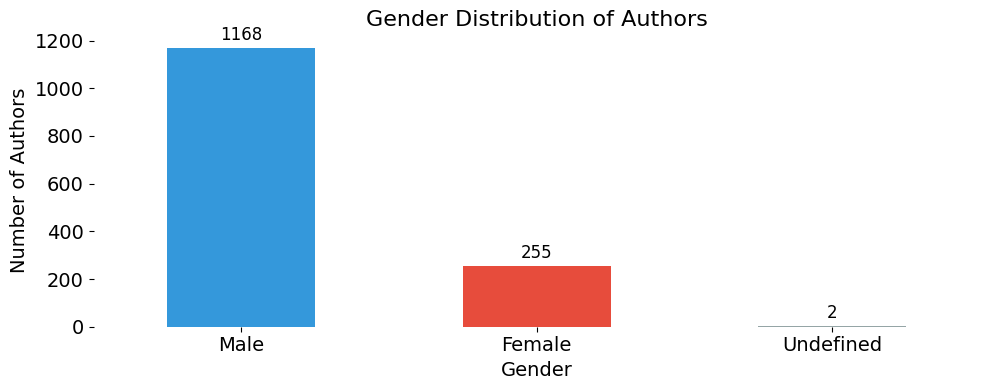